<a href="https://colab.research.google.com/github/felipebrsm/PUC_Sprint_1_ML-FBRSM/blob/main/notebook/MVP_FBRSM_PUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#MVP: *Machine Learning & Analytics*

Modelo de Classificação de Dados Geotécnicos por *Random Forest* e *K-Means*

**Autor:** Felipe Barreto R. S. Macedo

**Data:** 05/07/2026

**Matrícula:** XXXXX

**Dataset:** Ex: Global Dataset of Cone Penetration Test Results - Jianye Ching (http://140.112.12.21/issmge/Database/Global_CPT_3_1196/Global_CPT_3_1196.zip)


---



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema

A classificação de tipos de solo é de fundamental importância para a Engenharia Geotécnica, sendo o ensaio de Penetração de Cone Piezométrico (CPT) uma das formas mais confiáveis de obtenção de dados subterrâneos, em particular para projetos submarinos.

O resultado do CPT fornece parâmetros que permitem avaliar granulometria do solo, calcular valores de resistência ao cisalhamento e classificar o solo como arenoso e argiloso.

Usualmente é utilizado o método empírico de Robertson (1990, Soil Behavior Type - SBT), que calcula parâmetros normalizados a partir dos dados brutos do CPT e classifica o solo em 6 classes.

A proposta desse MVP é a criação de dois modelos que classifiquem camadas de solo a partir dos parâmetros brutos do CPT, destacando interfaces entre camadas, e compará-los com o resultado obtido pelo modelo de Robertson,  avaliando concordâncias, discordâncias e abrangência.

Para tanto, foi utilizado um dataset de resultados globais de CPT disponibilizado na internet. Os dados estão divididos por locação, organizados em planilhas .xlsx, e apresentam os parâmetros usuais de resultados de CPT:
- depth - Profundidade (m)
- qc - Resistência de ponta (MPa)
- fs - Atrito lateral (kPa)
- u2 - Poropressão (kPa)

Foram previstas as seguintes etapas:
1. Pré-processamento com compilação, padronização e normalização dos dados.
2. *Feature Engineering* com cálculo das tensões in-situ e dos índices normalizados.
3. Definição do Caso Base com a aplicação do método de Robertson pela classificação a partir do Ic.
4. Treinamento supervisionado de um modelo Random Forest.
5. Treinamento não supervisionada de um modelo K-Means.
6. Comparação entre Robertson, Random Forest e K-Means.

Como complemento, apresenta-se de forma visual de um perfil CPT do banco de dados classificado de acordo com Robertson e os dois modelos, permitindo avaliar quanto a classificação modelada converge ou diverge do método tradicional.





### 2. Reprodutibilidade e Ambiente



In [1]:
!pip install -q imbalanced-learn shap scipy


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.optimize import linear_sum_assignment

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, cross_validate
)
from sklearn.experimental import enable_halving_search_cv  # noqa: necessário antes do import abaixo
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, f1_score, accuracy_score,
    silhouette_score, adjusted_rand_score,
    normalized_mutual_info_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Utilitários
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 50
np.random.seed(SEED)

print("✅ Imports concluídos com sucesso.")


✅ Imports concluídos com sucesso.



## 3. Dados: carga, entendimento e qualidade
Os dados foram obtidos a partir do Dataset "Global Dataset of Cone Penetration Test Results - Jianye Ching", que compilou resultados de CPT terrestres em diversos países do mundo em planilhas Excel estruturadas em pastas de cada locação.

O pré-processamento via código em Python se resumiu à leitura, cópia e compilação dos resultados das planilhas individuais em um único database, com inclusão de colunas para a locação e furo de cada ensaio.

Para otimizar o tempo, foi escolhido o pré-processamento fora do notebook e sua disponibilização em .csv no repositório do GitHub.

### 3.1 Leitura do Database

In [36]:

# Configuração — altere aqui se o repositório ou caminho do arquivo mudar
USUARIO = 'felipebrsm'
REPO    = 'PUC_Sprint_1_ML-FBRSM'
BRANCH  = 'main'
ARQUIVO = 'data/processed/dataset_compilado.csv'

URL = f'https://raw.githubusercontent.com/{USUARIO}/{REPO}/{BRANCH}/{ARQUIVO}'

df_raw = pd.read_csv(URL)

df_raw['borehole_id'] = df_raw['locacao'].astype(str) + '_' + df_raw['ensaio'].astype(str)

print(f"📊 Dataset carregado: {df_raw.shape[0]:,} leituras, "
      f"{df_raw['borehole_id'].nunique()} furos")
print(f"   Profundidade máxima média: {df_raw.groupby('borehole_id')['depth'].max().mean():.1f} m")



📊 Dataset carregado: 475,083 leituras, 412 furos
   Profundidade máxima média: 15.0 m


## 3.2 Resumo do Dataset

In [37]:
dataset = df_raw

print('=' * 50)
print('RESUMO DO DATASET COMPILADO')
print('=' * 50)
print(f'Linhas totais  : {len(dataset):,}')
print(f'Locações       : {dataset["locacao"].nunique()}')
print(f'Ensaios únicos : {dataset[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Abas únicas    : {dataset[["locacao","ensaio","pagina"]].drop_duplicates().shape[0]}')
print()
print('Ensaios por locação:')
print(dataset.groupby('locacao')['ensaio'].nunique().to_string())

RESUMO DO DATASET COMPILADO
Linhas totais  : 475,083
Locações       : 23
Ensaios únicos : 412
Abas únicas    : 412

Ensaios por locação:
locacao
@Aranui                                   11
@Avondale                                 33
@Avonside                                 12
@Bexley                                   14
@Camberley (hospital)                     12
@Cashmere (high school)                   16
@Christchurch (Central City)              36
@Christchurch (Cnr Armagh & Durham St)     6
@Christchurch (Metro Sports Facility)     15
@Christchurch (stadium)                   12
@Hastings (hospital)                      13
@Lower Hutt (town hall)                   29
@Marshland                                24
@Marshland (road)                         27
@New Brighton (Willryan Ave)              10
@Parkland (Bower Ave)ONE                   8
@Parkland (Bower Ave)TWO                  11
@Port Nelson                              27
@Redcliffs (Main road)                     7


## 3.3 Estatísticas

In [38]:
print('ESTATÍSTICAS DESCRITIVAS')
print(dataset[['depth','qc','fs','u2']].describe().round(3))
print()
print('VALORES NULOS')
nulos = dataset.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')
print()
dataset.head()

ESTATÍSTICAS DESCRITIVAS
            depth          qc          fs           u2
count  475083.000  475083.000  472984.000   475083.000
mean        8.814       9.561      76.103      194.899
std         6.965       9.088     167.652    35535.280
min         0.000      -0.249   -7777.000   -90470.000
25%         3.487       2.140      27.700      -20.500
50%         6.993       6.950      56.500       14.000
75%        12.735      14.777      99.700       72.000
max       824.000      94.360    1674.000  9999000.000

VALORES NULOS
fs    2099
dtype: int64



,locacao,ensaio,pagina,depth,qc,fs,u2,borehole_id
0,@Aranui,1,工作表1,0.000000,0.4374,0.0,2.1,@Aranui_1
1,@Aranui,1,工作表1,0.010000,0.7282,0.0,2.1,@Aranui_1
2,@Aranui,1,工作表1,0.019999,0.6739,0.0,2.5,@Aranui_1
3,@Aranui,1,工作表1,0.029997,2.2015,0.0,2.3,@Aranui_1
4,@Aranui,1,工作表1,0.039996,2.6513,0.0,2.9,@Aranui_1


## 4. Feature Engineering

Foi realizado Feature Engineering para adequar os dados brutos (qc, fs e u2) com o tratamento exigido para o método de Robertson e para as modelagens em RF e K-Means.



## 4.1 Cálculo de Parâmetros


Parâmetros:

  - gamma_soil : peso específico do solo (kN/m³) — assumido constante
  - gamma_w    : peso específico da água (kN/m³)
  - u0_grad    : gradiente de pressão hidrostática (kN/m³)

Variáveis calculadas:
  - sigma_v0  : tensão vertical total (kPa)
  - sigma_v0p : tensão vertical efetiva (kPa)
  - u0        : pressão de poros hidrostática (kPa)
  - qt        : resistência de ponta corrigida (MPa)
  - Qt        : resistência normalizada (adim.)
  - Fr        : razão de atrito normalizada (%)
  - Bq        : parâmetro de pressão de poros (adimensional)
  - Ic        : índice de comportamento do solo (Robertson)

Obs. 1: Nos testes iniciais, observou-se que a informação de profundidade acabava gerando vazamento de dados a partir da relação estratigráfica. Optou-se pela utilização de profundidade normalizada.
      - depth_norm  : posição normalizada [0, 1] dentro do furo
      - delta_depth : incremento entre leituras consecutivas (m)
   
Obs. 2: Pela fórmula do Ic, observamos que o método de Robertson classifica os dados em um espaço Log-Log. Essa informação será útil no futuro ao avaliarmos o resultado do modelo K-Means.

In [39]:
def compute_cpt_features(df, gamma_soil=18.0, gamma_w=9.81, u0_grad=9.81):

    df = df.copy()

    # Tensões geostáticas
    df['sigma_v0']  = df['depth'] * gamma_soil                        # kPa
    df['u0']        = df['depth'] * u0_grad                           # kPa
    df['sigma_v0p'] = (df['sigma_v0'] - df['u0']).clip(lower=1.0)     # kPa efetivo

    # qt corrigido (simplificado: qt ≈ qc para solos drenados)
    df['qt'] = df['qc'] * 1000.0   # MPa → kPa

    # Variáveis normalizadas de Robertson
    df['Qt'] = (df['qt'] - df['sigma_v0']) / df['sigma_v0p']
    df['Qt'] = df['Qt'].clip(lower=0.1)

    df['Fr'] = (df['fs'] * 1000.0) / (df['qt'] - df['sigma_v0'] + 1e-6) * 100.0
    df['Fr'] = df['Fr'].clip(lower=0.01, upper=20.0)

    df['Bq'] = (df['u2'] - df['u0']) / (df['qt'] - df['sigma_v0'] + 1e-6)
    df['Bq'] = df['Bq'].clip(lower=-0.5, upper=2.0)

    # Ic — Robertson (2010): iterativo (simplificado com n=1 → SBTn)
    df['Ic'] = np.sqrt(
        (3.47 - np.log10(df['Qt'].clip(lower=0.1))) ** 2 +
        (np.log10(df['Fr'].clip(lower=0.1)) + 1.22) ** 2
    )

    return df


df_feat = compute_cpt_features(df_raw)

print("✅ Features calculadas.")
print(df_feat[['depth', 'Qt', 'Fr', 'Bq', 'Ic']].describe().round(3))


def add_depth_features(df, group_col='borehole_id'):
    df = df.copy()

    df['depth_norm'] = df.groupby(group_col)['depth'].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
    )
    df['delta_depth'] = df.groupby(group_col)['depth'].transform(
        lambda x: x.diff().fillna(x.diff().median())
    )
    return df

df_feat = add_depth_features(df_feat, group_col='borehole_id')  # ← ESSENCIAL

print("✅ Features calculadas.")
print(df_feat[['depth', 'depth_norm', 'delta_depth', 'Qt', 'Fr', 'Bq', 'Ic']].describe().round(3))


✅ Features calculadas.
            depth          Qt          Fr          Bq          Ic
count  475083.000  475083.000  472984.000  475083.000  472984.000
mean        8.814     267.472      19.864       0.012       2.944
std         6.965     843.070       1.620       0.142       0.333
min         0.000       0.100       0.010      -0.500       0.220
25%         3.487      43.332      20.000      -0.017       2.734
50%         6.993     137.526      20.000      -0.005       2.850
75%        12.735     255.510      20.000      -0.001       3.115
max       824.000   45551.760      20.000       2.000       5.132
✅ Features calculadas.
            depth  depth_norm  delta_depth          Qt          Fr  \
count  475083.000  475083.000   475083.000  475083.000  472984.000   
mean        8.814       0.500        0.009     267.472      19.864   
std         6.965       0.289        1.195     843.070       1.620   
min         0.000       0.000     -823.990       0.100       0.010   
25%       

## 4.2 Classificador de Robertson

Nessa etapa, classificamos os tipos de solo a partir do parâmetro Ic. Essa classificação será o Caso Base para análise desse MVP.

In [40]:

def robertson_classify_vectorized(Ic, Bq):
    """
    Versão vetorizada e EQUIVALENTE de robertson_classify — evita o
    .apply(axis=1) linha-a-linha (lento: chama uma função Python pura a
    cada uma das ~475 mil linhas). np.select avalia todas as condições em
    bloco, usando as rotinas vetorizadas do NumPy/C por baixo.

    Equivalência com a versão escalar (importante p/ linhas com Ic = NaN,
    ~2.099 linhas sem 'fs'): qualquer comparação com NaN é False, então a
    cascata de condições cai no 'default' — exatamente como o 'else' do
    laço if/elif escalar. Por isso o valor default já embute o teste de Bq,
    em vez de repetir a condição de Ic no último item da lista.

    Parâmetros
    ----------
    Ic, Bq : array-like (numpy array ou pandas Series.values)

    Retorna
    -------
    numpy array de inteiros (zonas 1 a 7)
    """
    conditions = [
        Ic > 3.60,
        Ic > 2.95,
        Ic > 2.60,
        Ic > 2.05,
        Ic > 1.31,
    ]
    choices = [1, 2, 3, 4, 5]
    default = np.where(Bq > 0.0, 7, 6)   # só é avaliado se nenhuma condição acima for True
    return np.select(conditions, choices, default=default)


# Aplicar classificação Robertson (vetorizado — troca .apply(axis=1) por np.select)
df_feat['zone_robertson'] = robertson_classify_vectorized(
    df_feat['Ic'].values, df_feat['Bq'].values
)

print("Distribuição classes Robertson calculadas:")
print(df_feat['zone_robertson'].value_counts().sort_index())

Distribuição classes Robertson calculadas:
zone_robertson
1     24350
2    144997
3    271578
4     30552
5       600
6      2575
7       431
Name: count, dtype: int64


## 5. Avaliação de Balanceamento dos Dados



Explicar e incluir discussão sobre o SMOTE (A FAZER)

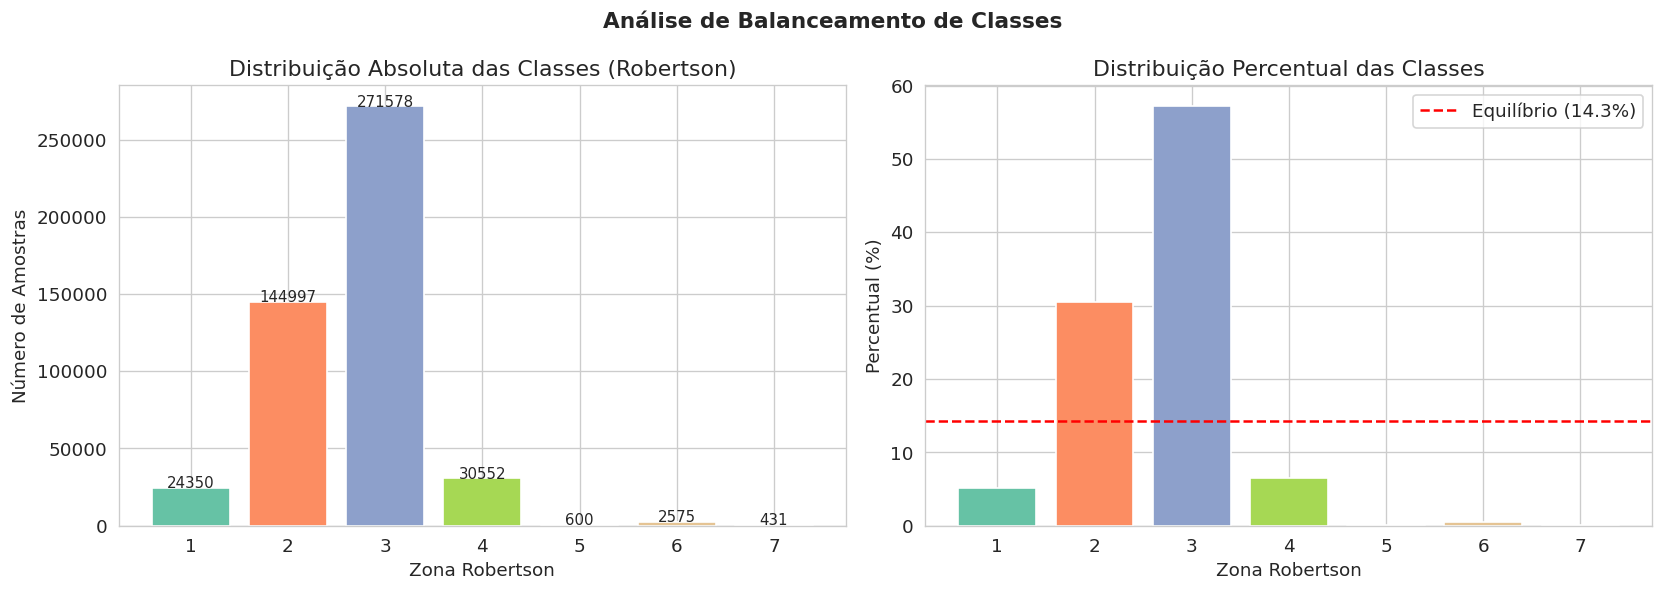


📊 Razão máx/mín de desbalanceamento: 630.1x
→ Será aplicado class_weight='balanced' no RF e SMOTE no treino.


In [41]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição absoluta
counts = df_feat['zone_robertson'].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(counts))))
axes[0].set_title('Distribuição Absoluta das Classes (Robertson)')
axes[0].set_xlabel('Zona Robertson')
axes[0].set_ylabel('Número de Amostras')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Distribuição percentual com linha de equilíbrio
pct = counts / counts.sum() * 100
axes[1].bar(pct.index.astype(str), pct.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(pct))))
axes[1].axhline(y=100/len(pct), color='red', linestyle='--',
                label=f'Equilíbrio ({100/len(pct):.1f}%)')
axes[1].set_title('Distribuição Percentual das Classes')
axes[1].set_xlabel('Zona Robertson')
axes[1].set_ylabel('Percentual (%)')
axes[1].legend()

plt.suptitle('Análise de Balanceamento de Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Razão de desbalanceamento
max_count = counts.max()
min_count = counts.min()
print(f"\n📊 Razão máx/mín de desbalanceamento: {max_count/min_count:.1f}x")
print("→ Será aplicado class_weight='balanced' no RF e SMOTE no treino.")



## 6. Definição de Features

Quando às features utilizadas no treinamento dos modelos, foram utilizadas duas estratégias:
1. Para o modelo Random Forest, propomos a utilização dos parâmetros básicos do CPT (qc, fs e u2), avaliando se o modelo conseguiria se aproximar da classificação de Robertson sem fornecer as funções por ele utilizadas: Ic = f(Bq, Fr).
2. Para o modelo K-Means, não supervisionado, a utilização de Qt, Fr e Bq são aceitáveis, já que não há vazamento de dados.



In [42]:

FEATURES_RF     = ['qc', 'fs', 'u2', 'depth_norm', 'delta_depth']
FEATURES_KMEANS = ['Qt', 'Fr', 'Bq']

TARGET = 'zone_robertson'
GROUPS = 'borehole_id'

# 'depth' mantida SOMENTE para plots — NÃO é feature do modelo
colunas_necessarias = list(dict.fromkeys(
    FEATURES_RF + FEATURES_KMEANS + [TARGET, GROUPS, 'Ic', 'depth']
    #                                                         ↑ para visualizações
))

assert len(colunas_necessarias) == len(set(colunas_necessarias)), \
    "Colunas duplicadas detectadas."

df_model = df_feat[colunas_necessarias].dropna()

print(f"✅ df_model: {df_model.shape[0]:,} linhas × {df_model.shape[1]} colunas")
print(f"   Colunas : {list(df_model.columns)}")
print(f"\n📐 Verificação das novas features:")
print(f"   depth_norm  range : [{df_model['depth_norm'].min():.3f}, {df_model['depth_norm'].max():.3f}]")
print(f"   delta_depth nulos : {df_model['delta_depth'].isna().sum()}")

✅ df_model: 472,984 linhas × 12 colunas
   Colunas : ['qc', 'fs', 'u2', 'depth_norm', 'delta_depth', 'Qt', 'Fr', 'Bq', 'zone_robertson', 'borehole_id', 'Ic', 'depth']

📐 Verificação das novas features:
   depth_norm  range : [0.000, 1.000]
   delta_depth nulos : 0


## 7. Holdout e Cross-Validation

In [45]:
X_rf     = df_model[FEATURES_RF].values
X_kmeans = df_model[FEATURES_KMEANS].values
y        = df_model[TARGET].values
groups   = df_model[GROUPS].values
print(f"X_rf.shape   : {X_rf.shape}  "
      f"(esperado: N linhas × {len(FEATURES_RF)} colunas)")
print(f"FEATURES_RF  : {FEATURES_RF}")
assert X_rf.shape[1] == len(FEATURES_RF), (
    f"X_rf tem {X_rf.shape[1]} colunas, esperado {len(FEATURES_RF)}."
)


X_rf.shape   : (472984, 5)  (esperado: N linhas × 5 colunas)
FEATURES_RF  : ['qc', 'fs', 'u2', 'depth_norm', 'delta_depth']


In [13]:
print("FEATURES_RF atual          :", FEATURES_RF)
print("df_model.columns           :", list(df_model.columns))
print()
print("Colunas de FEATURES_RF ausentes em df_model:")
for col in FEATURES_RF:
    presente = col in df_model.columns
    print(f"  {col:<10} : {'✅ presente' if presente else '❌ AUSENTE'}")

FEATURES_RF atual          : ['qc', 'fs', 'u2', 'depth_norm', 'delta_depth']
df_model.columns           : ['qc', 'fs', 'u2', 'depth_norm', 'delta_depth', 'Qt', 'Fr', 'Bq', 'zone_robertson', 'borehole_id', 'Ic', 'depth']

Colunas de FEATURES_RF ausentes em df_model:
  qc         : ✅ presente
  fs         : ✅ presente
  u2         : ✅ presente
  depth_norm : ✅ presente
  delta_depth : ✅ presente


## 8. Random Forest
1. k_neighbors=1 garante que o SMOTE funciona mesmo com subamostras
2. pequenas geradas pelo HalvingRandomSearchCV nas rodadas iniciais.
3. sampling_strategy fixo em 'not majority' — correto para multi-classe.



## 8.1 Pipeline para o Random Forest

In [52]:

N_FOLDS_CV = 3
FORCAR_NOVO_TREINO = False

steps = [('scaler', RobustScaler())]

steps.append(('clf', RandomForestClassifier(
    class_weight='balanced', random_state=SEED, n_jobs=1
)))
pipeline_rf = ImbPipeline(steps=steps)


## 8.2 Busca de Hiperparâmetros — HalvingRandomSearchCV

Busca com eliminação sucessiva (`resource='n_samples'`): a 1ª rodada testa vários candidatos usando só uma fração pequena do treino; a cada rodada seguinte, 1/`factor` dos candidatos avança e recebe mais dados, até sobrar o vencedor treinado com (quase) todo o conjunto de treino.

`min_resources=20000` foi calibrado para o tamanho real do dataset (garante amostras suficientes das classes raras — Z5+Z6+Z7 somam ~1% das linhas — já na primeira rodada).

A validação usa `GroupKFold` (agrupada por furo, `groups=groups_train`) em todas as rodadas, para não vazar dados do mesmo furo entre treino e validação dentro da própria busca.

In [54]:
gkf = GroupKFold(n_splits=N_FOLDS_CV)
param_dist = {
    'clf__n_estimators':     [40, 80, 120],
    'clf__max_depth':        [4, 6, 8],
    'clf__min_samples_leaf': [3, 5, 10],
    'clf__max_features':     ['sqrt', 'log2', 0.5],
}

# (+ cache via load_or_fit, se você já aplicou a versão da conversa anterior)
search = HalvingRandomSearchCV(
    pipeline_rf, param_dist,
    resource='n_samples', factor=3, min_resources=20000,
    cv=gkf, scoring='f1_weighted', random_state=SEED,
    return_train_score=True, n_jobs=-1, verbose=1
)
search.fit(X_train_rf, y_train, groups=groups_train)
print("✅ Melhor combinação:", search.best_params_)
print(f"   Melhor F1-weighted (CV): {search.best_score_:.4f}")


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 20000
max_resources_: 338734
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 16
n_resources: 20000
Fitting 3 folds for each of 16 candidates, totalling 48 fits
----------
iter: 1
n_candidates: 6
n_resources: 60000
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 2
n_candidates: 2
n_resources: 180000
Fitting 3 folds for each of 2 candidates, totalling 6 fits
✅ Melhor combinação: {'clf__n_estimators': 120, 'clf__min_samples_leaf': 3, 'clf__max_features': 'sqrt', 'clf__max_depth': 8}
   Melhor F1-weighted (CV): 0.8127


Fitting 3 folds for each of 2 candidates, totalling 6 fits
✅ Melhor combinação: {'clf__n_estimators': 120, 'clf__min_samples_leaf': 3, 'clf__max_features': 'sqrt', 'clf__max_depth': 8}
   Melhor F1-weighted (CV): 0.8127

## 8.3 Random Forest — Avaliação no Conjunto de Teste

O `HalvingRandomSearchCV` já refaz o fit automaticamente sobre o conjunto de treino completo (`refit=True`, padrão) usando os melhores hiperparâmetros encontrados. Aqui só avaliamos o modelo vencedor (`search.best_estimator_`) no conjunto de teste, que ficou de fora de toda a busca.

In [55]:
pipeline_rf = search.best_estimator_
y_pred_rf = pipeline_rf.predict(X_test_rf)


print("=" * 55)
print("📊 AVALIAÇÃO MODELO 1 — RANDOM FOREST (conjunto teste)")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"  Cohen's κ : {cohen_kappa_score(y_test, y_pred_rf):.4f}")

print("\n--- Relatório por Classe ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

📊 AVALIAÇÃO MODELO 1 — RANDOM FOREST (conjunto teste)

  Accuracy  : 0.7969
  F1-Score  : 0.8053
  Cohen's κ : 0.6593

--- Relatório por Classe ---
              precision    recall  f1-score   support

           1       0.62      0.84      0.71      4951
           2       0.75      0.83      0.79     38873
           3       0.93      0.77      0.84     80927
           4       0.47      0.88      0.61      9058
           5       0.46      0.87      0.60       201
           6       0.85      0.88      0.87       179
           7       0.72      1.00      0.84        61

    accuracy                           0.80    134250
   macro avg       0.68      0.87      0.75    134250
weighted avg       0.83      0.80      0.81    134250



In [78]:
def mode_filter_por_furo(df, pred_col, group_col='borehole_id', depth_col='depth', window=9):
    """
    Suaviza uma sequência de rótulos previstos aplicando o valor mais
    frequente (moda) numa janela centrada, furo a furo — nunca mistura
    leituras de furos diferentes. window deve ser ímpar.

    Puro pós-processamento: não precisa retreinar nada, custa segundos.
    """
    assert window % 2 == 1, "window deve ser ímpar (garante um centro bem definido)"
    df = df.copy()
    df['_ordem_original'] = np.arange(len(df))   # preserva a ordem p/ realinhar com y_test depois
    df_sorted = df.sort_values([group_col, depth_col])

    def _mode(s):
        return s.rolling(window, center=True, min_periods=1).apply(
            lambda x: pd.Series(x).mode().iloc[0], raw=False)

    df_sorted[pred_col + '_suave'] = df_sorted.groupby(group_col)[pred_col].transform(_mode)
    return df_sorted.sort_values('_ordem_original').drop(columns='_ordem_original')

## 8.4 Confusion Matrix - Random Forest x Robertson

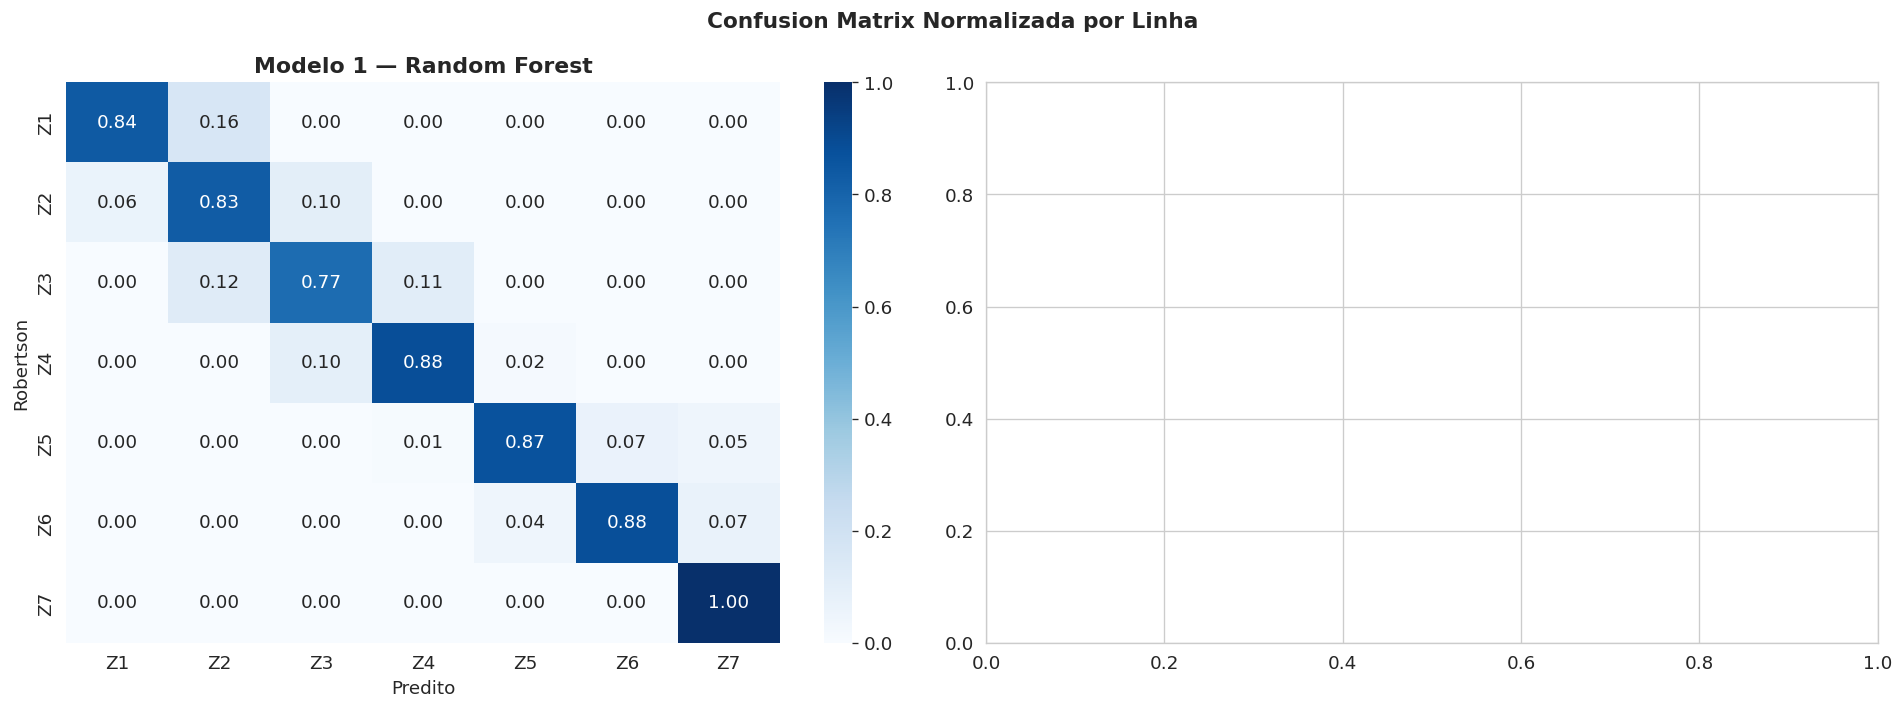

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = sorted(np.unique(np.concatenate([y_test, y_pred_rf])))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_rf, 'Modelo 1 — Random Forest'),
]):
    cm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[f'Z{c}' for c in classes],
                yticklabels=[f'Z{c}' for c in classes],
                ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Robertson')

plt.suptitle('Confusion Matrix Normalizada por Linha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.5 Random Forest - Feature Importance

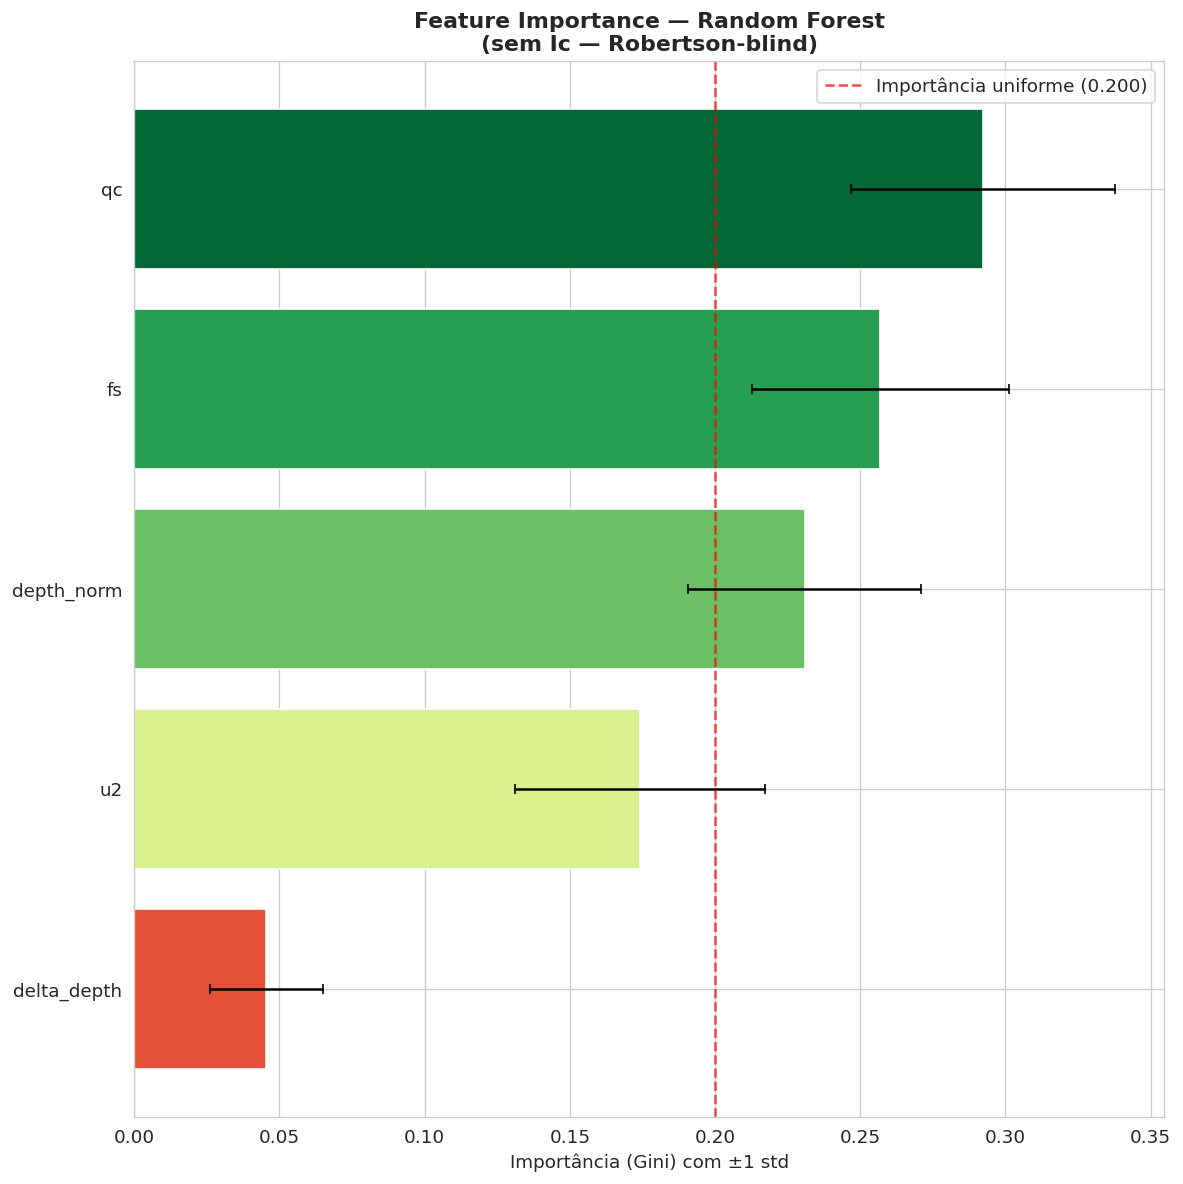


🔍 Top 5 features mais importantes:
    feature  importance      std
delta_depth    0.045531 0.019386
         u2    0.174267 0.043043
 depth_norm    0.230893 0.040091
         fs    0.256993 0.044358
         qc    0.292316 0.045458


In [57]:
rf_model   = pipeline_rf.named_steps['clf']
importances = rf_model.feature_importances_
std_imp     = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

feat_imp_df = pd.DataFrame({
    'feature':    FEATURES_RF,
    'importance': importances,
    'std':        std_imp
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.RdYlGn(feat_imp_df['importance'] / feat_imp_df['importance'].max())
bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
               xerr=feat_imp_df['std'], color=colors, capsize=3)
ax.set_xlabel('Importância (Gini) com ±1 std')
ax.set_title('Feature Importance — Random Forest\n(sem Ic — Robertson-blind)',
             fontweight='bold')
ax.axvline(x=1/len(FEATURES_RF), color='red', linestyle='--', alpha=0.7,
           label=f'Importância uniforme ({1/len(FEATURES_RF):.3f})')
ax.legend()
plt.tight_layout()
plt.show()

print("\n🔍 Top 5 features mais importantes:")
print(feat_imp_df.tail(5)[['feature', 'importance', 'std']].to_string(index=False))

## 9. K-Means

K-Means opera no espaço (Qt, Fr, Bq) — mesmo espaço de Robertson
Scaler separado para não contaminar o pipeline RF


## 9.1 Pipeline do K-Means

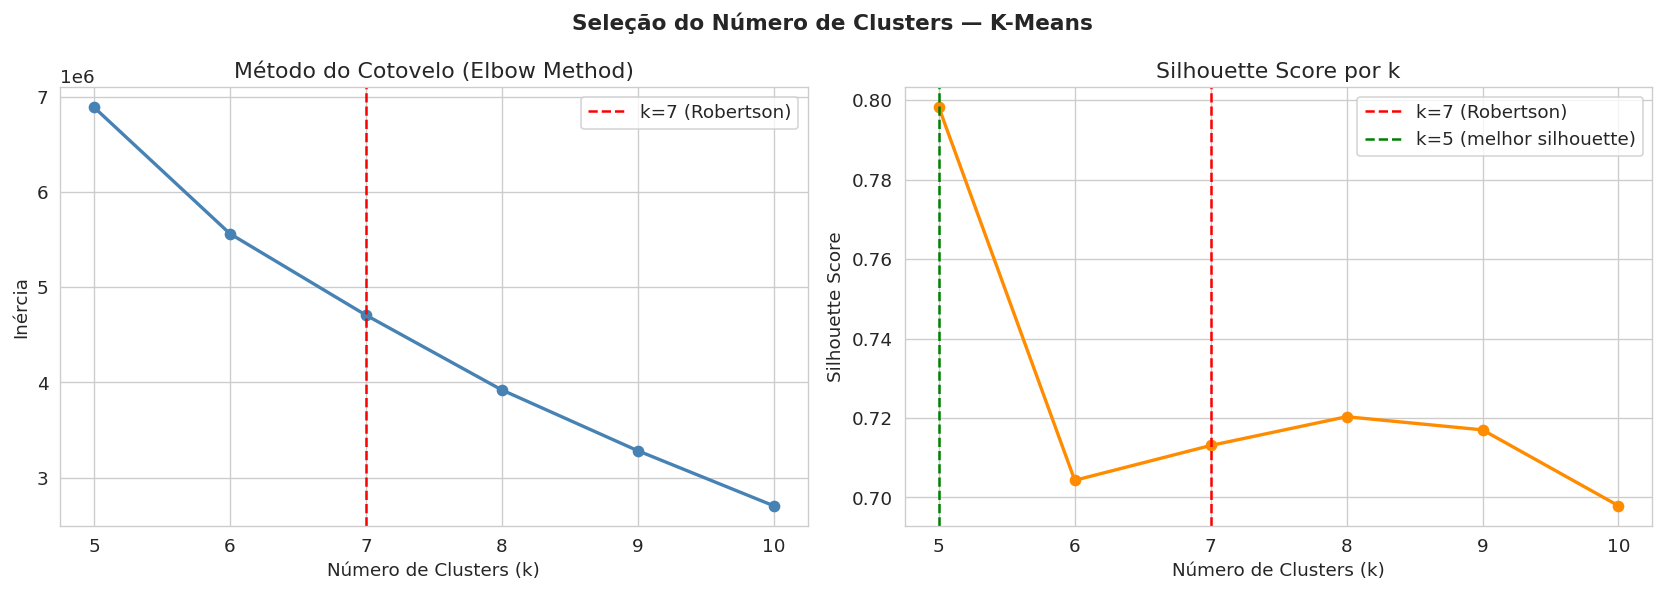


   k Robertson   : 7


In [58]:
scaler_km  = RobustScaler()
X_train_km_scaled = scaler_km.fit_transform(X_train_km)
X_test_km_scaled  = scaler_km.transform(X_test_km)

# ── Seleção do número de clusters ──────────────────────────
n_classes = len(np.unique(y))
k_range   = range(n_classes - 2, n_classes + 4)

inertia_list, silhouette_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    labels = km.fit_predict(X_train_km_scaled)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_train_km_scaled, labels,
                           metric='euclidean', sample_size=5000,
                           random_state=SEED)
    silhouette_list.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_list, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo (Elbow Method)')
axes[0].axvline(x=n_classes, color='red', linestyle='--', label=f'k={n_classes} (Robertson)')
axes[0].legend()

axes[1].plot(list(k_range), silhouette_list, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].axvline(x=n_classes, color='red', linestyle='--', label=f'k={n_classes} (Robertson)')
best_k = list(k_range)[np.argmax(silhouette_list)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'k={best_k} (melhor silhouette)')
axes[1].legend()

plt.suptitle('Seleção do Número de Clusters — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n   k Robertson   : {n_classes}")



## 9.2 K-Means - Treinamento do Modelo de Teste

 n_clusters = n_classes: número de zonas Robertson presentes em y_train.

 Calculado automaticamente na Célula 17 como len(np.unique(y)).

 Garante comparabilidade direta com Robertson independente do dataset.

In [71]:
n_classes = 10

print(f"   n_classes (zonas em y_train)  : {n_classes}")
print(f"   best_k    (melhor silhouette) : {best_k}")
print(f"   → Usando n_clusters = n_classes = {n_classes} por comparabilidade.\n")
kmeans = KMeans(
    n_clusters = n_classes,   # ← dinâmico, não hardcoded
    random_state=SEED,
    n_init=30,
    max_iter=500
)
kmeans.fit(X_train_km_scaled)

labels_train_raw = kmeans.labels_
labels_test_raw  = kmeans.predict(X_test_km_scaled)

sil_train = silhouette_score(X_train_km_scaled, labels_train_raw,
                              metric='euclidean', sample_size=5000,
                              random_state=SEED)

print(f"✅ K-Means treinado com k={n_classes}")
print(f"   Silhouette Score (treino): {sil_train:.4f}")
print(f"   Inércia final           : {kmeans.inertia_:.2f}")



   n_classes (zonas em y_train)  : 10
   best_k    (melhor silhouette) : 5
   → Usando n_clusters = n_classes = 10 por comparabilidade.

✅ K-Means treinado com k=10
   Silhouette Score (treino): 0.6979
   Inércia final           : 2703831.06


## 10. Mecanismo de Correspondência

🔗 Algoritmo Húngaro (Treino)
   Cluster 0 → Zona Robertson 3
   Cluster 1 → Zona Robertson 1
   Cluster 2 → Zona Robertson 5
   Cluster 4 → Zona Robertson 2
   Cluster 5 → Zona Robertson 7
   Cluster 6 → Zona Robertson 6
   Cluster 9 → Zona Robertson 4


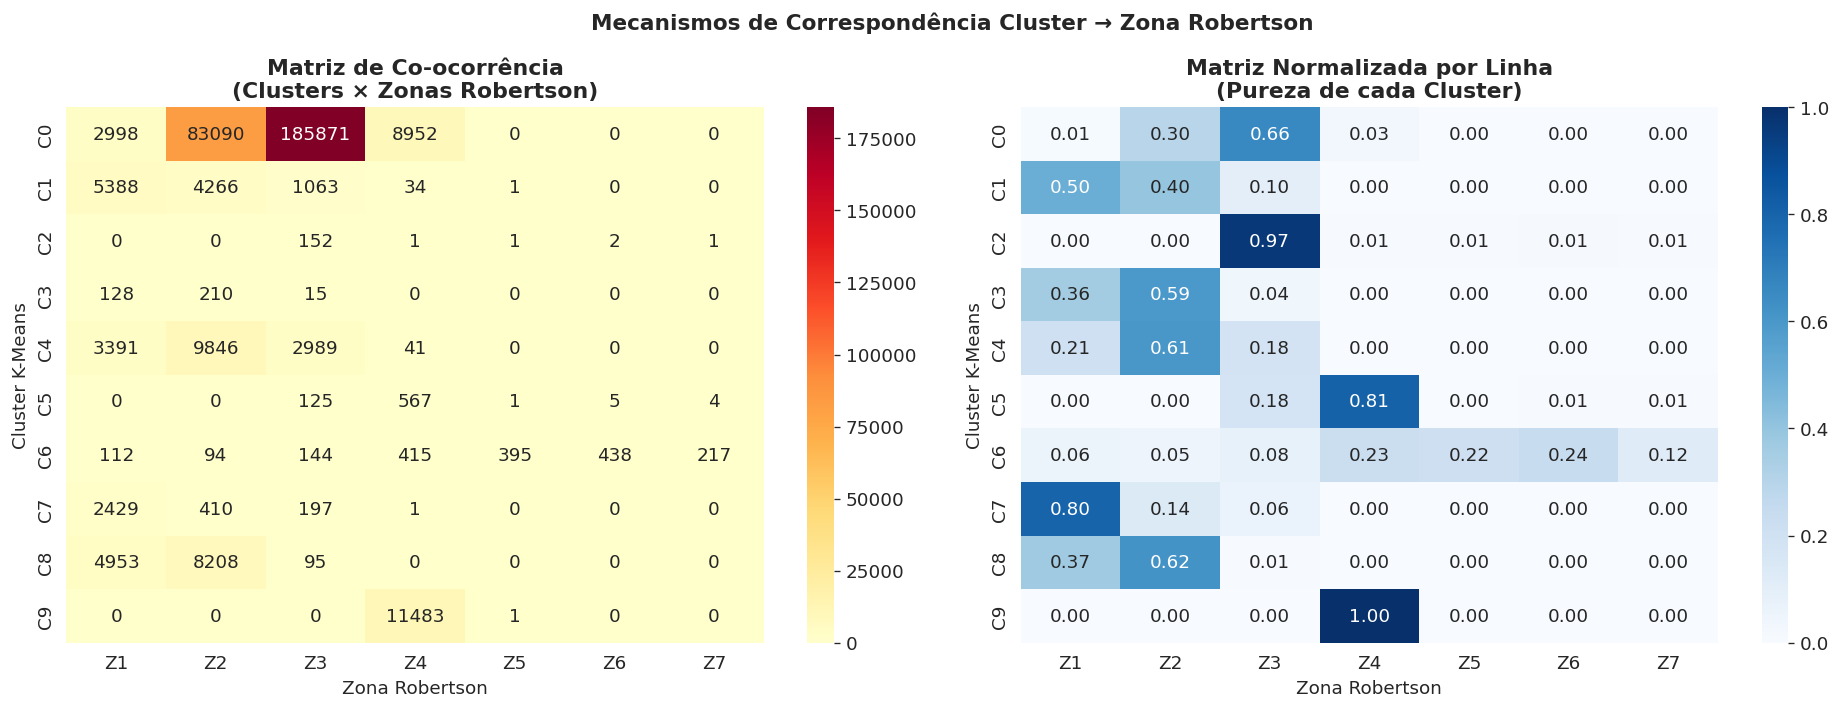

In [72]:
def hungarian_mapping(cluster_labels, true_labels):
    """
    Encontra o mapeamento ótimo (maximiza concordância global)
    usando o Algoritmo Húngaro (scipy.optimize.linear_sum_assignment).

    Retorna: dict {cluster_id: classe_robertson}
    """
    unique_clusters = np.unique(cluster_labels)
    unique_classes  = np.unique(true_labels)

    # Construir matriz de co-ocorrência (linhas=clusters, colunas=classes)
    cost_matrix = np.zeros((len(unique_clusters), len(unique_classes)), dtype=int)
    for i, c in enumerate(unique_clusters):
        for j, z in enumerate(unique_classes):
            cost_matrix[i, j] = np.sum((cluster_labels == c) & (true_labels == z))

    # linear_sum_assignment MINIMIZA custo → usar negativo para MAXIMIZAR
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    mapping = {}
    for r, c in zip(row_ind, col_ind):
        mapping[unique_clusters[r]] = unique_classes[c]


    return mapping, cost_matrix, unique_clusters, unique_classes
# Aplicar os dois mecanismos no conjunto de TREINO

map_hungarian, cost_matrix, u_clusters, u_classes = hungarian_mapping(
    labels_train_raw, y_train
)

print("🔗 Algoritmo Húngaro (Treino)")
print("=" * 55)
for cluster, zone in sorted(map_hungarian.items()):
    print(f"   Cluster {cluster} → Zona Robertson {zone}")

# Visualizar a Matriz de Co-ocorrência usada pelo Húngaro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de co-ocorrência (contagem)
sns.heatmap(cost_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[f'Z{c}' for c in u_classes],
            yticklabels=[f'C{c}' for c in u_clusters],
            ax=axes[0])
axes[0].set_title('Matriz de Co-ocorrência\n(Clusters × Zonas Robertson)', fontweight='bold')
axes[0].set_xlabel('Zona Robertson')
axes[0].set_ylabel('Cluster K-Means')

# Matriz normalizada por linha (% de cada cluster em cada zona)
cost_norm = cost_matrix / (cost_matrix.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cost_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Z{c}' for c in u_classes],
            yticklabels=[f'C{c}' for c in u_clusters],
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz Normalizada por Linha\n(Pureza de cada Cluster)', fontweight='bold')
axes[1].set_xlabel('Zona Robertson')
axes[1].set_ylabel('Cluster K-Means')

plt.suptitle('Mecanismos de Correspondência Cluster → Zona Robertson',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




## 11. Comparação K-Means Mapeado - Robertson

**Nota de performance:** `silhouette_score` sem `sample_size` calcula a matriz de distância par-a-par completa — O(n²). No conjunto de teste (~134 mil linhas) isso trava por minutos. Usamos `sample_size=5000` (mesmo padrão já usado no treino, Célula 9.1/9.2), que dá uma estimativa confiável e é ordens de magnitude mais rápido.

In [73]:
# Aplicar mapeamento Húngaro no teste
y_pred_km = np.array([map_hungarian.get(l, -1) for l in labels_test_raw])

print("=" * 55)
print("📊 AVALIAÇÃO MODELO 2 — K-MEANS (mapeamento húngaro)")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred_km):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_km, average='weighted', zero_division=0):.4f}")
print(f"  Cohen's κ : {cohen_kappa_score(y_test, y_pred_km):.4f}")

print("\n--- Métricas não supervisionadas ---")
ari = adjusted_rand_score(y_test, labels_test_raw)
nmi = normalized_mutual_info_score(y_test, labels_test_raw)
# sample_size evita o custo O(n²) da matriz de distância completa em ~134 mil
# linhas de teste (mesmo padrão usado no treino — ver Célula 9.1/9.2)
sil_test = silhouette_score(X_test_km_scaled, labels_test_raw,
                             sample_size=5000, random_state=SEED)
print(f"  ARI (Adjusted Rand Index)       : {ari:.4f}")
print(f"  NMI (Normalized Mutual Info)    : {nmi:.4f}")
print(f"  Silhouette Score (teste, amostrado) : {sil_test:.4f}")

📊 AVALIAÇÃO MODELO 2 — K-MEANS (mapeamento húngaro)

  Accuracy  : 0.6564
  F1-Score  : 0.5875
  Cohen's κ : 0.2760

--- Métricas não supervisionadas ---
  ARI (Adjusted Rand Index)       : 0.2777
  NMI (Normalized Mutual Info)    : 0.2913
  Silhouette Score (teste, amostrado) : 0.7062


## 12. Comparação Global dos Modelos

**Nota metodológica:** Robertson não entra como uma linha na tabela abaixo. Como `zone_robertson` é o próprio alvo (`TARGET`) usado no treino — não existe um rótulo independente ("ground truth") em dados reais de CPT —, comparar `y_test` com `zone_robertson` recalculado seria comparar a coluna com ela mesma (Accuracy = F1 = Kappa = 1,0000 sempre, por construção; não é uma métrica informativa). A comparação que importa, e que reportamos, é: o quanto RF e K-Means conseguem reproduzir a classificação de Robertson.

📊 COMPARAÇÃO FINAL DOS MODELOS (vs. classificação de Robertson)
                    Accuracy      F1-W     Kappa                Tipo
Random Forest (M1)  0.796864  0.805298  0.659346      Supervisionado
K-Means (M2)        0.656372  0.587519  0.275959  Não Supervisionado


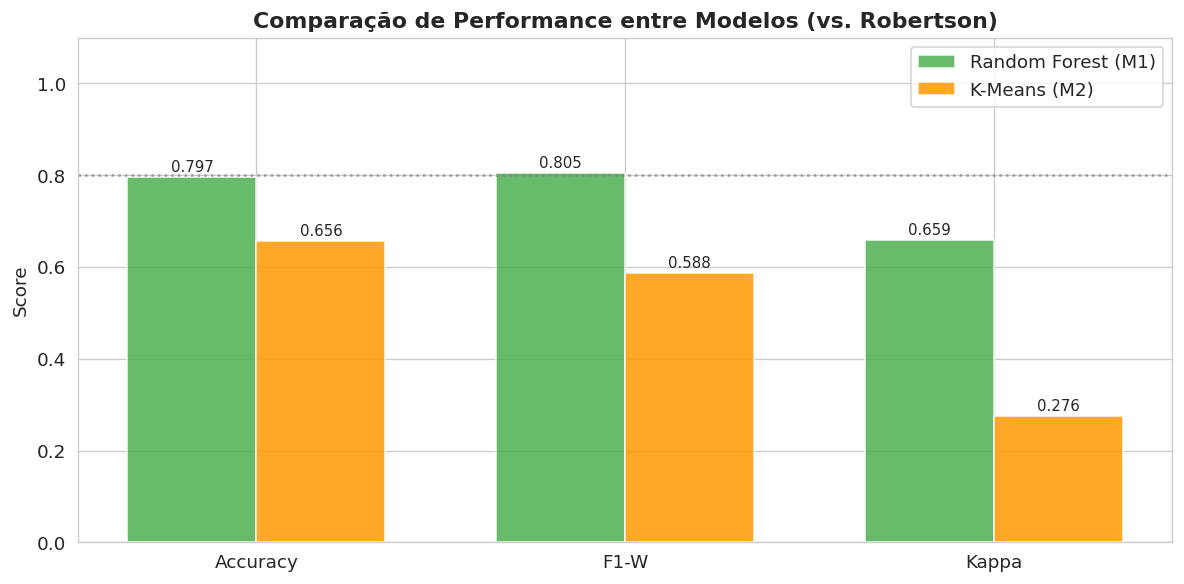

In [83]:
metrics = {
    'Random Forest (M1)': {
        'Accuracy':  accuracy_score(y_test, y_pred_rf),
        'F1-W':      f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_pred_rf),
        'Tipo':      'Supervisionado'
    },
    'K-Means (M2)': {
        'Accuracy':  accuracy_score(y_test, y_pred_km),
        'F1-W':      f1_score(y_test, y_pred_km, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_pred_km),
        'Tipo':      'Não Supervisionado'
    }
}

df_metrics = pd.DataFrame(metrics).T
print("=" * 65)
print("📊 COMPARAÇÃO FINAL DOS MODELOS (vs. classificação de Robertson)")
print("=" * 65)
print(df_metrics.to_string())

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
metric_names = ['Accuracy', 'F1-W', 'Kappa']
x = np.arange(len(metric_names))
width = 0.35
colors_models = ['#4CAF50', '#FF9800']

for i, (model_name, row) in enumerate(df_metrics.iterrows()):
    vals = [row[m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_models[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação de Performance entre Modelos (vs. Robertson)', fontweight='bold')
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.7, label='Referência 0.80')
plt.tight_layout()
plt.show()

## 13. Visualização de Perfil Classificado

🔍 Visualizando perfil do Furo @Avondale_26 (conjunto de teste)...


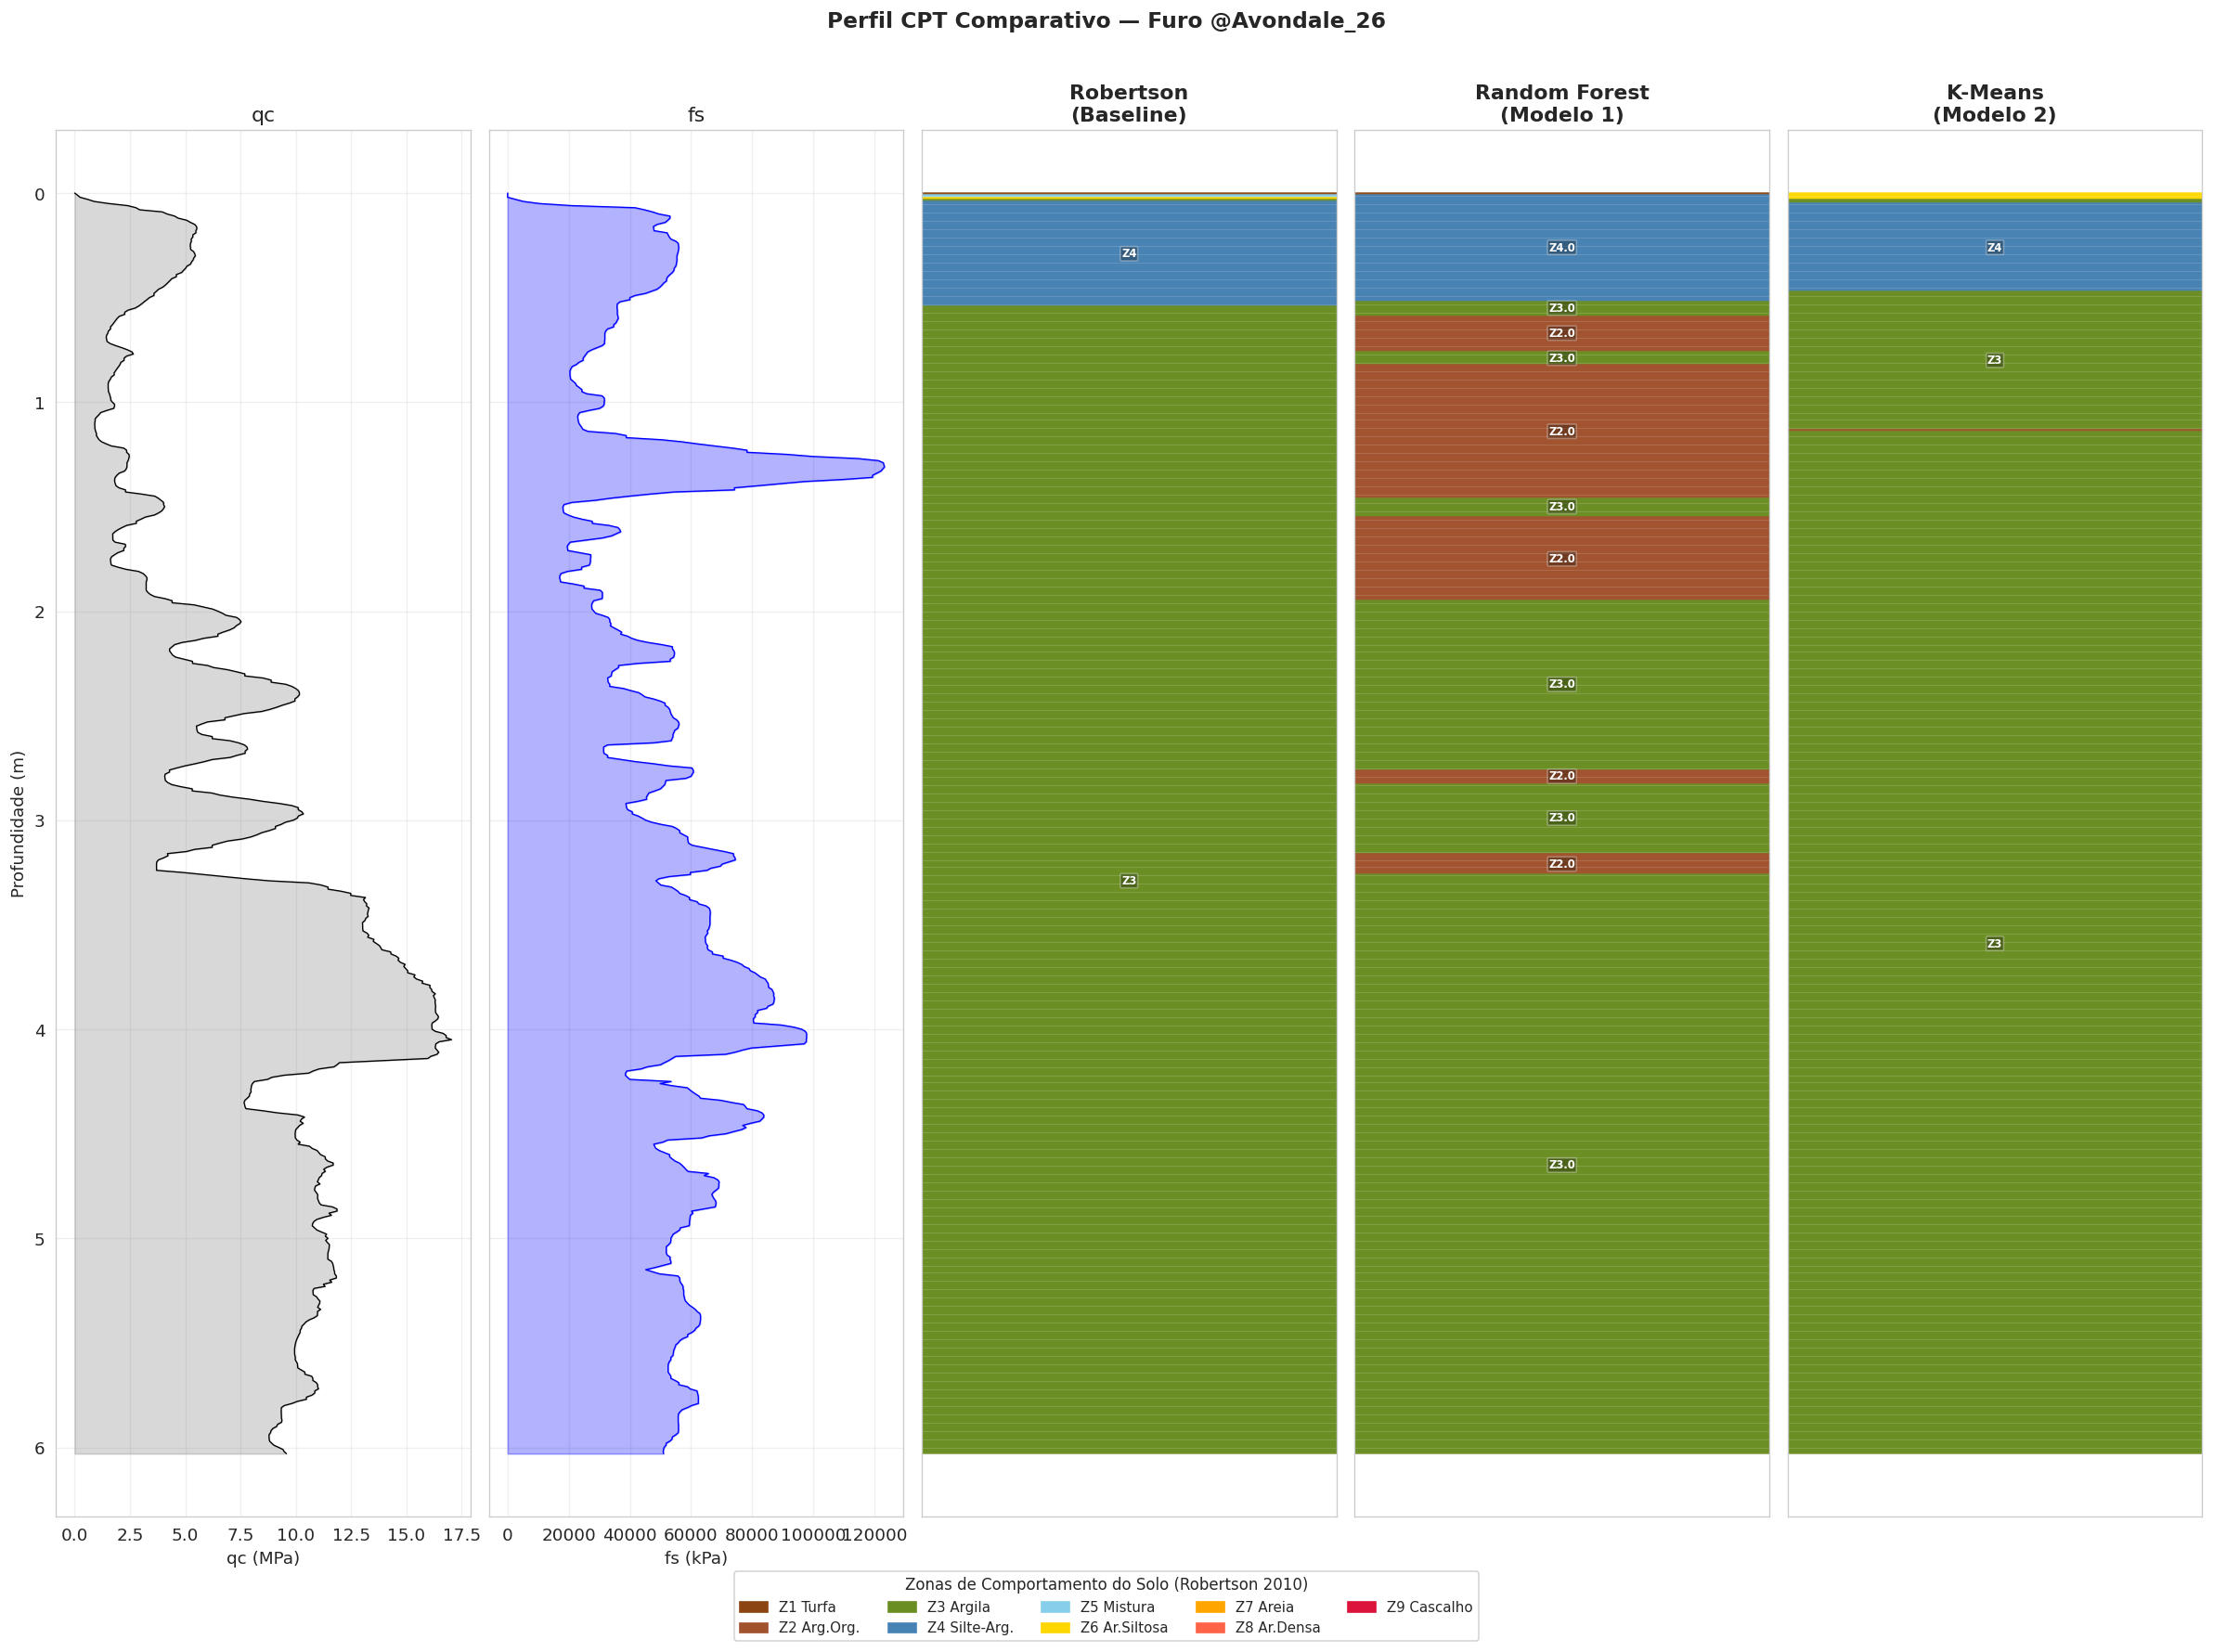

In [84]:

# Paleta de cores padronizada para zonas Robertson (1 a 9)
ZONE_COLORS = {
    1: '#8B4513',   # turfa — marrom escuro
    2: '#A0522D',   # argila orgânica — marrom
    3: '#6B8E23',   # argila — verde oliva
    4: '#4682B4',   # silte argiloso — azul aço
    5: '#87CEEB',   # mistura — azul claro
    6: '#FFD700',   # areia siltosa — amarelo
    7: '#FFA500',   # areia — laranja
    8: '#FF6347',   # areia densa — vermelho tomate
    9: '#DC143C',   # areia/cascalho — vermelho escuro
}

ZONE_LABELS = {
    1: 'Z1 Turfa',
    2: 'Z2 Arg.Org.',
    3: 'Z3 Argila',
    4: 'Z4 Silte-Arg.',
    5: 'Z5 Mistura',
    6: 'Z6 Ar.Siltosa',
    7: 'Z7 Areia',
    8: 'Z8 Ar.Densa',
    9: 'Z9 Cascalho',
}

def plot_cpt_profile(df_bh, rf_pipeline, km_model, km_scaler, km_mapping,
                     borehole_id, features_rf, features_km):
    """
    Gera o perfil CPT comparativo com 5 painéis:
    [qc | fs | Robertson | Random Forest | K-Means]
    """
    df = df_bh[df_bh['borehole_id'] == borehole_id].copy()
    df = df.sort_values('depth')
    depth = df['depth'].values

    # Predições
    X_rf_bh = df[features_rf].values
    X_km_bh = df[features_km].values

    WINDOW_SUAVIZACAO = 9  # parametrizável

    pred_rf_raw = rf_pipeline.predict(X_rf_bh)
    tmp = pd.DataFrame({'borehole_id': borehole_id, 'depth': depth, 'pred_rf': pred_rf_raw})
    pred_rf = mode_filter_por_furo(tmp, 'pred_rf', window=WINDOW_SUAVIZACAO)['pred_rf_suave'].values

    pred_km_raw = km_model.predict(km_scaler.transform(X_km_bh))
    pred_km = np.array([km_mapping.get(l, -1) for l in pred_km_raw])
    robertson = df['zone_robertson'].values

    fig, axes = plt.subplots(1, 5, figsize=(20, 14), sharey=True)
    fig.suptitle(f'Perfil CPT Comparativo — Furo {borehole_id}',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── Painel 1: qc ─────────────────────────────────────
    axes[0].plot(df['qc'], depth, 'k-', linewidth=0.8)
    axes[0].fill_betweenx(depth, 0, df['qc'], alpha=0.3, color='gray')
    axes[0].set_xlabel('qc (MPa)')
    axes[0].set_ylabel('Profundidade (m)')
    axes[0].set_title('qc')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)

    # ── Painel 2: fs ─────────────────────────────────────
    axes[1].plot(df['fs'] * 1000, depth, 'b-', linewidth=0.8)
    axes[1].fill_betweenx(depth, 0, df['fs'] * 1000, alpha=0.3, color='blue')
    axes[1].set_xlabel('fs (kPa)')
    axes[1].set_title('fs')
    axes[1].grid(True, alpha=0.3)

    # ── Painéis 3–5: classificações ──────────────────────
    for ax, (preds, title) in zip(
        axes[2:],
        [
            (robertson, 'Robertson\n(Baseline)'),
            (pred_rf,   'Random Forest\n(Modelo 1)'),
            (pred_km,   'K-Means\n(Modelo 2)'),
        ]
    ):
        # Criar barras coloridas por zona
        for i in range(len(depth) - 1):
            zone = preds[i]
            color = ZONE_COLORS.get(zone, '#CCCCCC')
            ax.fill_betweenx(
                [depth[i], depth[i+1]],
                0, 1,
                color=color, alpha=0.85
            )

        ax.set_xlim(0, 1)
        ax.set_xticks([])
        ax.set_title(title, fontweight='bold')
        ax.grid(False)

        # Adicionar rótulo da zona no centro de cada segmento
        zone_changes = np.where(np.diff(preds) != 0)[0]
        segments = np.split(np.arange(len(depth)), zone_changes + 1)
        for seg in segments:
            if len(seg) > 5:   # só rotular segmentos suficientemente espessos
                mid = seg[len(seg)//2]
                ax.text(0.5, depth[mid],
                        f'Z{preds[mid]}',
                        ha='center', va='center',
                        fontsize=7, fontweight='bold',
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.1',
                                  facecolor='black', alpha=0.3))

    # Legenda global
    legend_patches = [
        mpatches.Patch(color=ZONE_COLORS.get(z, '#CCCCCC'),
                       label=ZONE_LABELS.get(z, f'Z{z}'))
        for z in sorted(ZONE_COLORS.keys())
    ]
    fig.legend(handles=legend_patches,
               loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.04),
               fontsize=9,
               title='Zonas de Comportamento do Solo (Robertson 2010)',
               title_fontsize=10)

    plt.tight_layout()
    plt.show()
    return fig


# Selecionar um furo de teste para visualização
test_borehole_ids = sorted(test_boreholes)
selected_bh = test_borehole_ids[10]   # primeiro furo do conjunto de teste

print(f"🔍 Visualizando perfil do Furo {selected_bh} (conjunto de teste)...")

fig_profile = plot_cpt_profile(
    df_bh        = df_model,
    rf_pipeline  = pipeline_rf,
    km_model     = kmeans,
    km_scaler    = scaler_km,
    km_mapping   = map_hungarian,
    borehole_id  = selected_bh,
    features_rf  = FEATURES_RF,
    features_km  = FEATURES_KMEANS
)


## 13. Resumo Executivo Final

In [76]:
print("=" * 65)
print("📋  RESUMO EXECUTIVO — MVP CPT CLASSIFICATION")
print("=" * 65)

print(f"""
DATASET
  Furos totais          : {df_raw['borehole_id'].nunique()}
  Leituras totais       : {df_raw.shape[0]}
  Features (RF)         : {len(FEATURES_RF)} (sem Ic — Robertson-blind)
  Holdout               : Split por furo (sem vazamento espacial)

REFERÊNCIA — CLASSIFICAÇÃO DE ROBERTSON (2010)
  Método                 : Determinístico via índice Ic
  Papel neste MVP        : Define o alvo (TARGET) — não é um modelo avaliado
                            (não há rótulo independente em dados reais de CPT)

MODELO 1 — RANDOM FOREST (Supervisionado)
  Accuracy (teste)      : {accuracy_score(y_test, y_pred_rf):.4f}
  F1-Weighted           : {f1_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}
  Cohen's κ             : {cohen_kappa_score(y_test, y_pred_rf):.4f}
  Balanceamento         : {'SMOTE + class_weight=balanced' if USAR_SMOTE else "class_weight='balanced'"}
  Hiperparâmetros       : {search.best_params_}
  Validação             : GroupKFold (k={N_FOLDS_CV}, agrupado por furo) + HalvingRandomSearchCV

MODELO 2 — K-MEANS (Não Supervisionado)
  k                     : {n_classes} (comparável com Robertson)
  Mapeamento            : Algoritmo Húngaro (ótimo)
  Accuracy mapeada      : {accuracy_score(y_test, y_pred_km):.4f}
  ARI                   : {adjusted_rand_score(y_test, labels_test_raw):.4f}
  NMI                   : {normalized_mutual_info_score(y_test, labels_test_raw):.4f}
  Silhouette (teste, amostrado) : {silhouette_score(X_test_km_scaled, labels_test_raw, sample_size=5000, random_state=SEED):.4f}
""")

📋  RESUMO EXECUTIVO — MVP CPT CLASSIFICATION

DATASET
  Furos totais          : 412
  Leituras totais       : 475083
  Features (RF)         : 5 (sem Ic — Robertson-blind)
  Holdout               : Split por furo (sem vazamento espacial)

REFERÊNCIA — CLASSIFICAÇÃO DE ROBERTSON (2010)
  Método                 : Determinístico via índice Ic
  Papel neste MVP        : Define o alvo (TARGET) — não é um modelo avaliado
                            (não há rótulo independente em dados reais de CPT)

MODELO 1 — RANDOM FOREST (Supervisionado)
  Accuracy (teste)      : 0.7969
  F1-Weighted           : 0.8053
  Cohen's κ             : 0.6593
  Balanceamento         : class_weight='balanced'
  Hiperparâmetros       : {'clf__n_estimators': 120, 'clf__min_samples_leaf': 3, 'clf__max_features': 'sqrt', 'clf__max_depth': 8}
  Validação             : GroupKFold (k=3, agrupado por furo) + HalvingRandomSearchCV

MODELO 2 — K-MEANS (Não Supervisionado)
  k                     : 10 (comparável com Roberts

## Apêndice 1: Espaço Qt × Fr com Zonas de Robertson


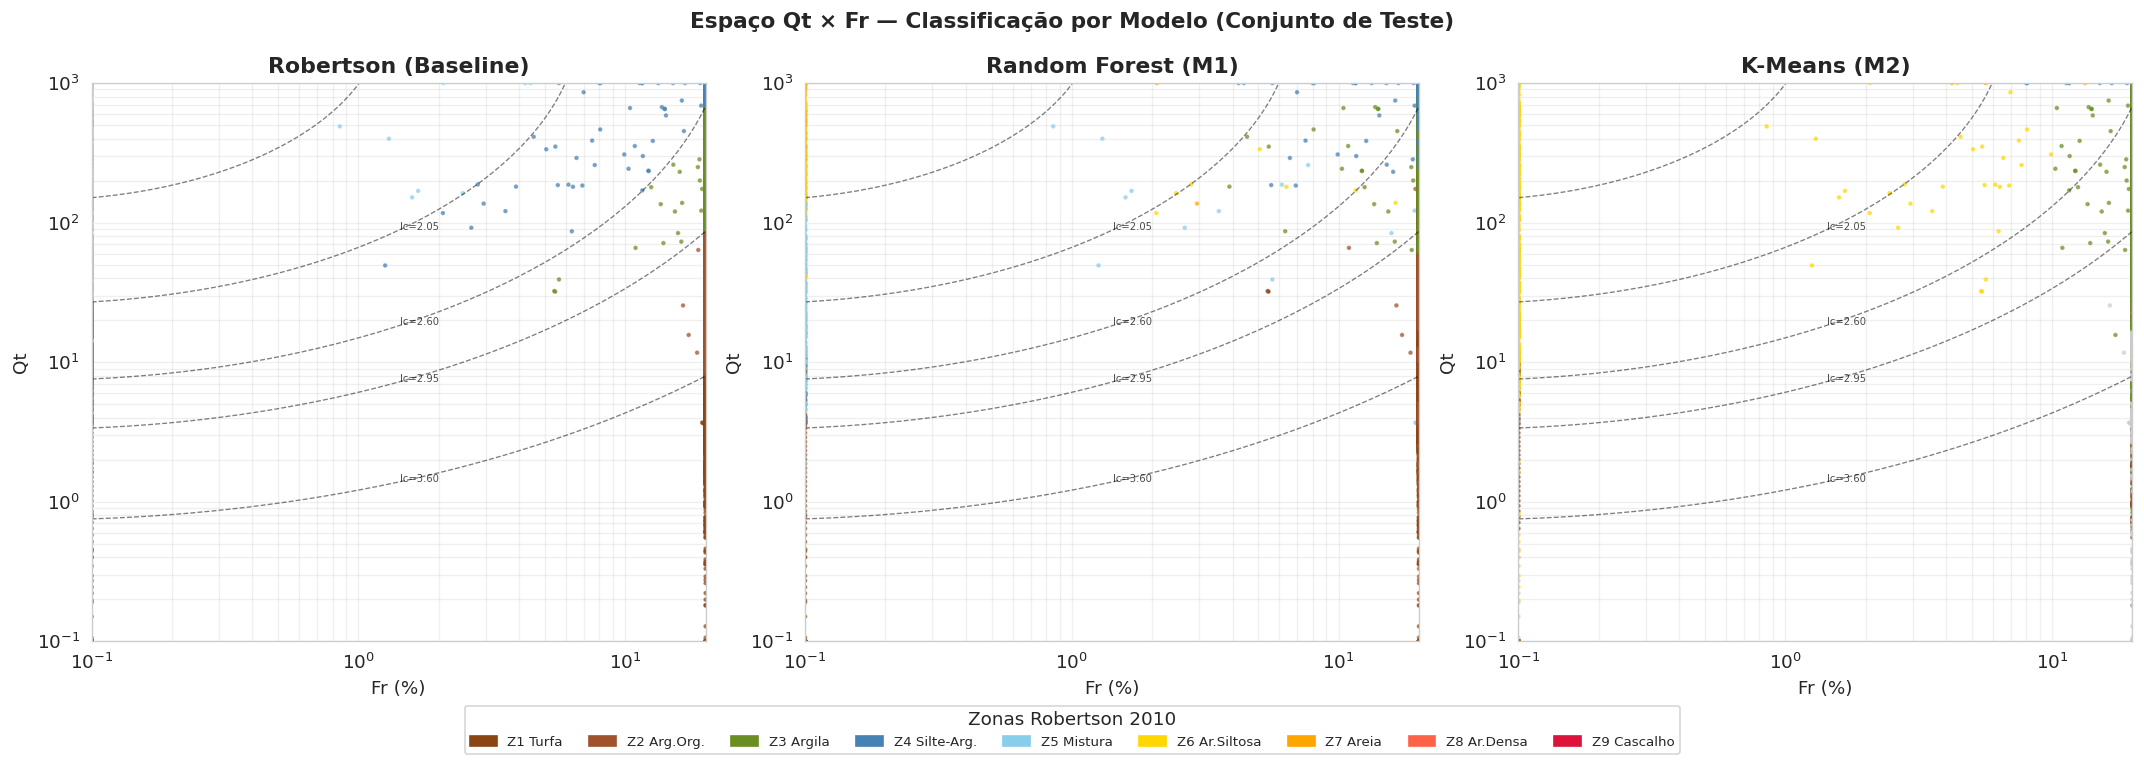

In [77]:
# Visualizar no espaço de Robertson onde cada modelo prediz cada classe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_plot = df_model.iloc[test_idx].copy()
df_plot['pred_rf'] = y_pred_rf
df_plot['pred_km'] = y_pred_km

Qt_clip = np.clip(df_plot['Qt'], 0.1, 1000)
Fr_clip = np.clip(df_plot['Fr'], 0.1, 20)

for ax, (col, title) in zip(axes, [
    ('zone_robertson', 'Robertson (Baseline)'),
    ('pred_rf',        'Random Forest (M1)'),
    ('pred_km',        'K-Means (M2)'),
]):
    zones = df_plot[col].values
    colors = [ZONE_COLORS.get(z, '#CCCCCC') for z in zones]
    ax.scatter(Fr_clip, Qt_clip, c=colors, s=3, alpha=0.6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Fr (%)')
    ax.set_ylabel('Qt')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0.1, 20)
    ax.set_ylim(0.1, 1000)
    ax.grid(True, alpha=0.3, which='both')

    # Linhas de referência Ic
    for Ic_line, label in [(1.31, 'Ic=1.31'), (2.05, 'Ic=2.05'),
                            (2.60, 'Ic=2.60'), (2.95, 'Ic=2.95'), (3.60, 'Ic=3.60')]:
        Fr_arr = np.logspace(-1, 1.3, 200)
        # Qt a partir de Ic: (3.47 - log Qt)² + (log Fr + 1.22)² = Ic²
        # → log Qt = 3.47 - sqrt(Ic² - (log Fr + 1.22)²)  [quando possível]
        disc = Ic_line**2 - (np.log10(Fr_arr) + 1.22)**2
        valid = disc >= 0
        Qt_arr = np.where(valid, 10**(3.47 - np.sqrt(np.where(valid, disc, 0))), np.nan)
        ax.plot(Fr_arr, Qt_arr, 'k--', linewidth=0.8, alpha=0.5)
        idx_mid = len(Fr_arr)//2
        if not np.isnan(Qt_arr[idx_mid]):
            ax.text(Fr_arr[idx_mid], Qt_arr[idx_mid], label,
                    fontsize=6, color='black', alpha=0.7)

# Legenda
legend_patches = [
    mpatches.Patch(color=ZONE_COLORS.get(z, '#CCC'), label=ZONE_LABELS.get(z, f'Z{z}'))
    for z in sorted(ZONE_COLORS.keys())
]
fig.legend(handles=legend_patches, loc='lower center', ncol=9,
           bbox_to_anchor=(0.5, -0.06), fontsize=8,
           title='Zonas Robertson 2010')

plt.suptitle('Espaço Qt × Fr — Classificação por Modelo (Conjunto de Teste)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

